In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn keras tensorflow

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.11.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/opt_einsum-3.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/igraph-0.11.8-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from keras.models import Model, Sequential
from keras.layers import Input, Dense, Dropout, LSTM, Bidirectional
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import tensorflow as tf



2025-08-13 18:39:09.818128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755110349.837820 1017615 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755110349.843941 1017615 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755110349.860397 1017615 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755110349.860416 1017615 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755110349.860418 1017615 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv('cleaned_merged_heart_dataset.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
le = LabelEncoder()
df = df.apply(lambda col: le.fit_transform(col) if col.dtypes == 'object' else col)

X = df.drop('target', axis=1)
y = df['target']

X = pd.get_dummies(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)


In [4]:
input_dim = X_resampled.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_resampled, X_resampled, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

encoder = Model(input_layer, encoded)
X_encoded = encoder.predict(X_resampled)



I0000 00:00:1755110352.197265 1017615 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1097 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB MIG 3g.40gb, pci bus id: 0000:87:00.0, compute capability: 8.0
I0000 00:00:1755110353.950620 1406806 service.cc:152] XLA service 0x7fec7c005fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755110353.950641 1406806 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB MIG 3g.40gb, Compute Capability 8.0
2025-08-13 18:39:13.974864: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755110354.104707 1406806 cuda_dnn.cc:529] Loaded cuDNN version 90501
I0000 00:00:1755110356.587721 1406806 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step  


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_resampled, test_size=0.2, random_state=42)

In [12]:
X_train_lstm = np.expand_dims(X_train, axis=1)
X_test_lstm = np.expand_dims(X_test, axis=1)

model = Sequential()
model.add(Bidirectional(LSTM(32, return_sequences=False), input_shape=(1, X_train.shape[1])))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(X_train_lstm, y_train, validation_split=0.2, epochs=80, batch_size=32, callbacks=[early_stop])


Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6608 - loss: 0.6271 - val_accuracy: 0.7252 - val_loss: 0.5653
Epoch 2/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7184 - loss: 0.5517 - val_accuracy: 0.7220 - val_loss: 0.5167
Epoch 3/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7360 - loss: 0.5156 - val_accuracy: 0.7572 - val_loss: 0.4862
Epoch 4/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7464 - loss: 0.5016 - val_accuracy: 0.7636 - val_loss: 0.4737
Epoch 5/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7592 - loss: 0.4824 - val_accuracy: 0.7796 - val_loss: 0.4595
Epoch 6/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7640 - loss: 0.4719 - val_accuracy: 0.7891 - val_loss: 0.4435
Epoch 7/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7680 - loss: 0.4688 - val_accuracy: 0.7923 - val_loss: 0.4377
Epoch 8/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7792 - loss: 0.4557 - val_accuracy: 0.7987 - val_loss: 0.4257
E

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 
Confusion Matrix:
 [[170  21]
 [  4 196]]
Accuracy: 0.9361
Precision: 0.9032
Recall (Sensitivity): 0.9800
Specificity: 0.8901
F1 Score: 0.9400


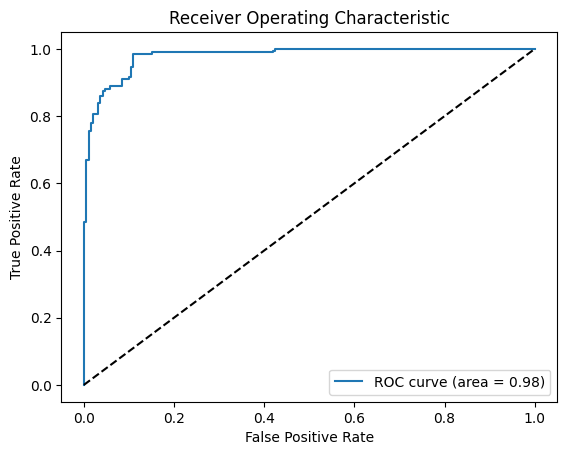

In [13]:
y_pred_prob = model.predict(X_test_lstm)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


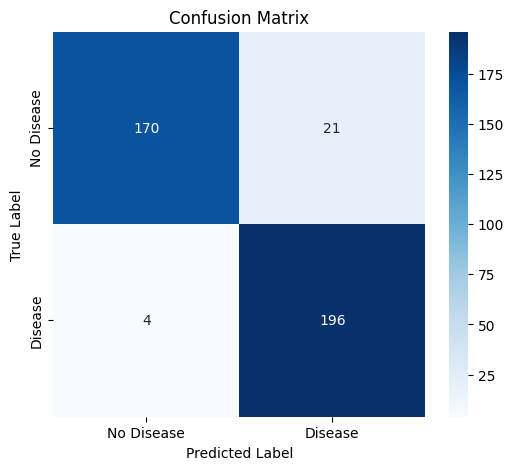

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
